In [1]:
import pandas as pd

def load_data(file_path):

    try:
        df = pd.read_csv(file_path)
        print(f"Data loaded successfully. Shape: {df.shape}")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# File path to the dataset
file_path = r'C:\Users\samy\Downloads\time_series_covid19_confirmed_global.csv'
df = load_data(file_path)


Data loaded successfully. Shape: (166, 1147)


In [2]:
import numpy as np

def clean_data(df):

    df['Province/State'] = df['Province/State'].fillna('Unknown')
    
    df.iloc[:, 4:] = df.iloc[:, 4:].apply(lambda x: x.replace(np.nan, 0))
    
    df = df.drop_duplicates()
    
    print("Data cleaned. Missing values filled and duplicates removed.")
    print("\nCleaned Data (First 5 rows):")
    print(df.head())  
    
    return df

df_cleaned = clean_data(df)


Data cleaned. Missing values filled and duplicates removed.

Cleaned Data (First 5 rows):
  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0        Unknown    Afghanistan  33.93911  67.709953        0        0   
1        Unknown        Albania  41.15330  20.168300        0        0   
2        Unknown        Algeria  28.03390   1.659600        0        0   
3        Unknown        Andorra  42.50630   1.521800        0        0   
4        Unknown         Angola -11.20270  17.873900        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...   2/28/23    3/1/23    3/2/23  \
0        0        0        0        0  ...  209322.0  209340.0  209358.0   
1        0        0        0        0  ...  334391.0  334408.0  334408.0   
2        0        0        0        0  ...  271441.0  271448.0  271463.0   
3        0        0        0        0  ...   47866.0   47875.0   47875.0   
4        0        0        0        0  ...  105255.0  105277.0  105277.0   

     3/3

In [3]:
import numpy as np

def explore_data(df):

    print("\n--- Dataset Head ---\n", df.head())
    print("\n--- Dataset Info ---")
    print(df.info())
    print("\n--- Missing Values ---\n", df.isnull().sum())
    print("\n--- Statistical Summary ---\n", df.describe())

def analyze_global_trend(df):
    
    case_data = df.iloc[:, 4:].values  
    global_trend = np.sum(case_data, axis=0)  
    
    
    global_trend = pd.Series(global_trend, index=df.columns[4:])
    
    print("\n--- Global Trend Summary ---\n", global_trend.head())
    return global_trend

def analyze_top_countries(df, top_n=5):

    country_totals = df.groupby("Country/Region").sum().iloc[:, 4:].sum(axis=1)
    top_countries = country_totals.sort_values(ascending=False).head(top_n)
    
    print(f"\n--- Top {top_n} Countries by Total Cases ---\n", top_countries)
    return top_countries


explore_data(df_cleaned)


global_trend = analyze_global_trend(df_cleaned)


top_countries = analyze_top_countries(df_cleaned, top_n=5)



--- Dataset Head ---
   Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0        Unknown    Afghanistan  33.93911  67.709953        0        0   
1        Unknown        Albania  41.15330  20.168300        0        0   
2        Unknown        Algeria  28.03390   1.659600        0        0   
3        Unknown        Andorra  42.50630   1.521800        0        0   
4        Unknown         Angola -11.20270  17.873900        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...   2/28/23    3/1/23    3/2/23  \
0        0        0        0        0  ...  209322.0  209340.0  209358.0   
1        0        0        0        0  ...  334391.0  334408.0  334408.0   
2        0        0        0        0  ...  271441.0  271448.0  271463.0   
3        0        0        0        0  ...   47866.0   47875.0   47875.0   
4        0        0        0        0  ...  105255.0  105277.0  105277.0   

     3/3/23    3/4/23    3/5/23    3/6/23    3/7/23    3/8/23    3/9/23  
0

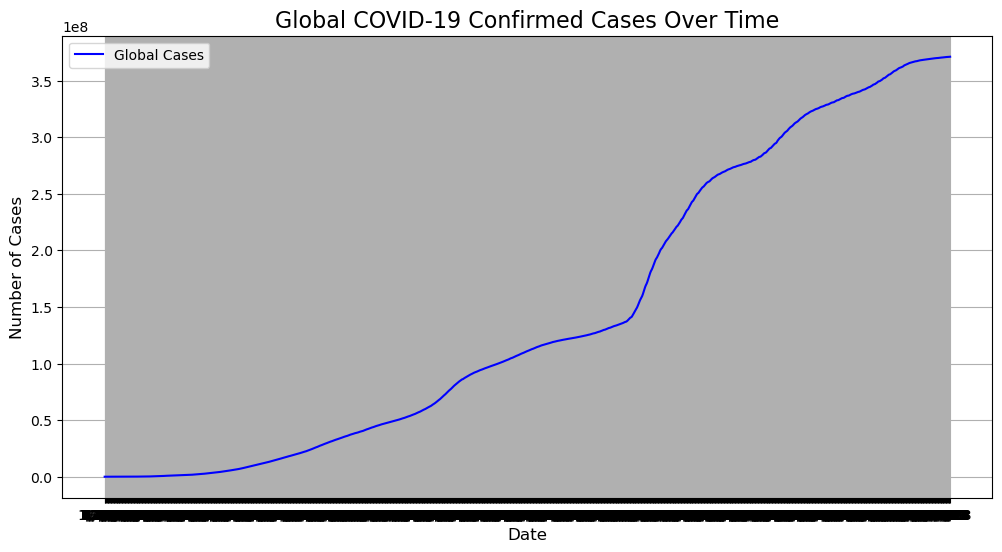

C:\Users\samy\AppData\Local\Temp\ipykernel_13968\3532863178.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


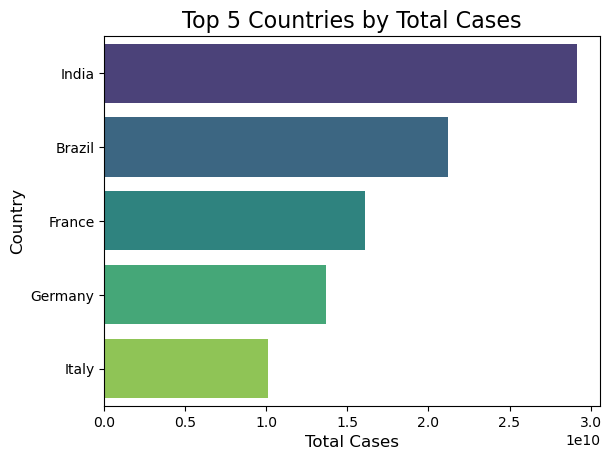

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_global_trend(global_trend):
    
    plt.figure(figsize=(12, 6))
    plt.plot(global_trend.index, global_trend.values, label="Global Cases", color="blue")
    plt.title("Global COVID-19 Confirmed Cases Over Time", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Number of Cases", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_top_countries(top_countries):

    sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
    plt.title(f"Top {len(top_countries)} Countries by Total Cases", fontsize=16)
    plt.xlabel("Total Cases", fontsize=12)
    plt.ylabel("Country", fontsize=12)
    plt.show()

plot_global_trend(global_trend)

plot_top_countries(top_countries)


In [5]:
import numpy as np

def calculate_statistics(df):

    stats = {
        "mean": np.mean(df.iloc[:, 4:].values, axis=0),  
        "median": np.median(df.iloc[:, 4:].values, axis=0),  
        "std_dev": np.std(df.iloc[:, 4:].values, axis=0),  
        "min": np.min(df.iloc[:, 4:].values, axis=0),  
        "max": np.max(df.iloc[:, 4:].values, axis=0)   
    }
    
    print("\n--- Basic Statistics ---\n")
    for key, value in stats.items():
        print(f"{key.capitalize()}:\n{value}\n")
    
    return stats


statistics = calculate_statistics(df_cleaned.iloc[:, 4:])



--- Basic Statistics ---

Mean:
[1.26024096e+01 1.74578313e+01 3.33614458e+01 ... 2.23478599e+06
 2.23518985e+06 2.23565855e+06]

Median:
[    0.     0.     0. ... 96895. 96895. 96895.]

Std_dev:
[8.34079739e+01 1.12350388e+02 2.76197637e+02 ... 7.23985032e+06
 7.24092041e+06 7.24192063e+06]

Min:
[0. 0. 0. ... 0. 0. 0.]

Max:
[1.0580000e+03 1.4230000e+03 3.5540000e+03 ... 4.4689919e+07 4.4690298e+07
 4.4690738e+07]



Data loaded successfully. Shape: (166, 1147)
Data cleaned. Missing values filled and duplicates removed.

Cleaned Data (First 5 rows):
  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0        Unknown    Afghanistan  33.93911  67.709953        0        0   
1        Unknown        Albania  41.15330  20.168300        0        0   
2        Unknown        Algeria  28.03390   1.659600        0        0   
3        Unknown        Andorra  42.50630   1.521800        0        0   
4        Unknown         Angola -11.20270  17.873900        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...   2/28/23    3/1/23    3/2/23  \
0        0        0        0        0  ...  209322.0  209340.0  209358.0   
1        0        0        0        0  ...  334391.0  334408.0  334408.0   
2        0        0        0        0  ...  271441.0  271448.0  271463.0   
3        0        0        0        0  ...   47866.0   47875.0   47875.0   
4        0        0        0        0  .

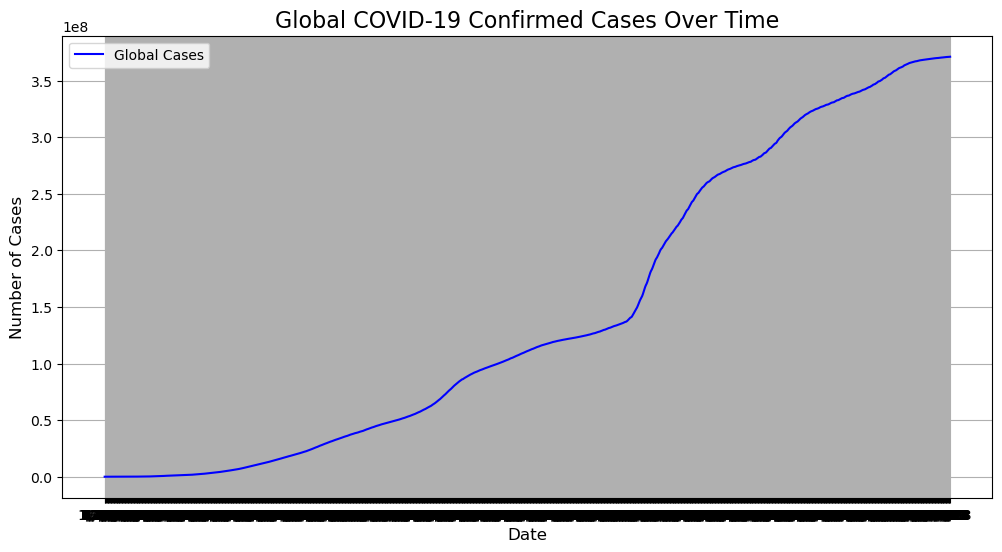

C:\Users\samy\AppData\Local\Temp\ipykernel_13968\3532863178.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


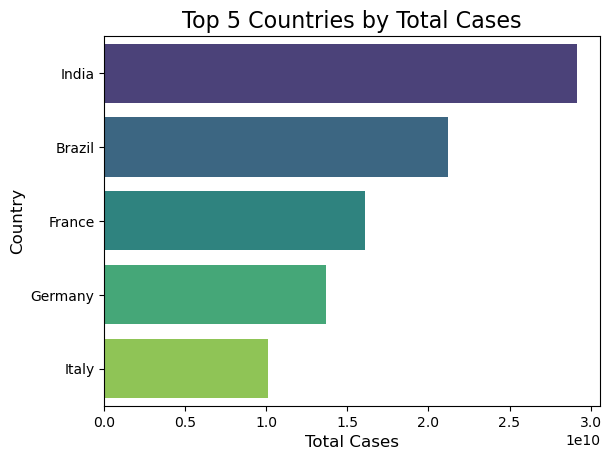

In [6]:

df = load_data(file_path)

df_cleaned = clean_data(df)

explore_data(df_cleaned)

global_trend = analyze_global_trend(df_cleaned)

top_countries = analyze_top_countries(df_cleaned, top_n=5)

statistics = calculate_statistics(df_cleaned.iloc[:, 4:])

plot_global_trend(global_trend)

plot_top_countries(top_countries)
